# Blood Rheology: Modified t-ETV Model (Mt-ETV) Analysis and Visualization

## Overview

The **Modified thermodynamic Extended Thixotropic Vector (Mt-ETV) model** emerges from a rigorous tensorial reformulation of the original t-ETV framework, with a primary objective: ensuring **thermodynamic consistency** through an explicit Helmholtz free-energy formulation.

### Key Conceptual Differences from t-ETV

The Mt-ETV model retains the same three structural variables as t-ETV:
1. **Cellular conformation tensor** ($\mathbf{c}^C$): Describes the deformation and orientation of individual red blood cells
2. **Rouleaux conformation tensor** ($\mathbf{c}^R$): Describes the deformation and orientation of cell aggregates (rouleaux formations)
3. **Structure parameter** ($\lambda$): Quantifies the degree of aggregation, ranging from 0 (fully dispersed) to 1 (fully aggregated)

However, the evolution equations are fundamentally reformed:

- **Structural destruction is now microstructurally coupled**: Instead of being driven directly by the imposed shear rate, the breakup of aggregates is controlled by the internal deformation stored in the rouleaux conformation tensor through the term $-2\lambda\dot{\gamma}_0 c_{12}^R$. This introduces an additional level of microstructural dynamics: $\dot{\gamma} \rightarrow \mathbf{c}^R \rightarrow \lambda$.

- **Onsager relaxation framework**: The structural relaxation $\dot{\lambda}_{\rm relax}$ is derived from a mobility tensor $M(\lambda)$ and the gradient of the Helmholtz free energy, rather than being postulated phenomenologically.

- **Thermodynamic consistency**: All dissipative mechanisms (stress relaxation, structural evolution, conformation tensor evolution) are explicitly tied to entropy production, ensuring the model satisfies the second law of thermodynamics.

### Simplified Variant: $\Phi = 0$

In this notebook, we implement the **Simple Mt-ETV** variant, which sets $\Phi(\lambda e^{-I_R}) = 0$ in the Helmholtz free energy. This simplification eliminates energetic coupling between $\lambda$ and $\mathbf{c}^R$, while preserving the essential kinematic coupling through $\mathbf{g}$. The resulting equations remain thermodynamically sound and are tractable for numerical integration.

## Workflow

In the following cells, we will: 
1. Derive and symbolically construct the Simple Mt-ETV model equations using SymPy
2. Lambdify the equations to obtain efficient numerical functions
3. Solve the resulting differential equations via time integration using the same protocols as t-ETV (startup, relaxation, shear-rate reversal)
4. Generate comprehensive visualizations and store the results for direct comparison with the original t-ETV model
5. Perform parameter optimization to calibrate the Mt-ETV model against experimental data, seeking to match the predictive capability of the original t-ETV while maintaining thermodynamic rigor

In [1]:
import sympy as sp
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
from extras import show 

sp.init_printing()

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "text.latex.preamble": r"\usepackage{amsfonts}\usepackage{amsmath}"
})

## 1. Symbolic Construction

We define the symbolic variables that will be used throughout the Simple Mt-ETV model:

- **Independent variable**: time $t$
- **Imposed shear rate**: $\dot{\gamma}_0$ (constant for simple shear flow startup)
- **State variables**: components of the conformation tensors ($c^C_{ij}$, $c^R_{ij}$) and the structure parameter ($\lambda$)
- **Model parameters**: material constants governing viscosity, elasticity, and structural evolution

**Note on Mt-ETV architecture**: Unlike t-ETV where parameters like $\tau_{\rm break}$, $\tau_{\rm aggr}$, and $d$ are independent phenomenological inputs, in Mt-ETV these emerge implicitly from the Helmholtz free energy $\hat{f}_c$ and the mobility tensor $M(\lambda)$. This structure-preserving formulation ensures that all constitutive relations are thermodynamically consistent.

In [2]:
# --- independent variable and imposed shear rate ---
t = sp.symbols('t', real=True)
gamma0 = sp.symbols(r'\dot{\gamma_0}', real=True)   # dot(gamma)_0, constant (simple shear startup)

# --- state: components of conformation tensors + lambda ---
cCxx, cCxy, cCyy, cCzz = sp.symbols(r'c^C_{xx} c^C_{xy} c^C_{yy} c^C_{zz}', real=True)
cRxx, cRxy, cRyy, cRzz = sp.symbols(r'c^R_{xx} c^R_{xy} c^R_{yy} c^R_{zz}', real=True)
lam = sp.symbols(r'\lambda', positive=True)

state_syms = (cCxx, cCxy, cCyy, cCzz, cRxx, cRxy, cRyy, cRzz, lam)

# --- model parameters ---
# Cellular contribution (same as t-ETV)
G_C, muC0, muCinf, tauC             = sp.symbols(r'G_C \mu_{0-C} \mu_{\infty-C} \tau_C', positive=True)

# Rouleaux and structural parameters (modified for Mt-ETV)
G_R, tau_R, tau_lam                 = sp.symbols(r'G_R \tau_R \tau_\lambda', positive=True)
m                                   = sp.symbols('m', positive=True)

# Mt-ETV specific: mobility function parameters
# M(λ) = (2ρ/G_R τ_λ) λ^(1-m) (1-λ) [1 + |τ_aggr γ̇₀|^d]
# We keep τ_aggr and d for the mobility, but they are now part of the relaxation mechanism
tau_aggr, dexp                      = sp.symbols(r'\tau_{aggr} d', positive=True)

# Physical parameters
rho, Temp                           = sp.symbols('rho T', positive=True)

param_syms = (G_C, muC0, muCinf, tauC, G_R, tau_R, tau_lam, m, tau_aggr, dexp, rho, Temp)

### Cellular Viscosity (Cross-like Model)

The viscosity of the cellular contribution follows a shear-rate-dependent (shear-thinning) model:

$$\eta_C(\dot{\gamma}_0) = \mu_{C,\infty} + \frac{\mu_{C,0} - \mu_{C,\infty}}{1 + \tau_C \dot{\gamma}_0}$$

where $\mu_{C,0}$ is the zero-shear viscosity, $\mu_{C,\infty}$ is the infinite-shear viscosity, and $\tau_C$ is the relaxation time.

**Note**: This cellular viscosity expression is identical in both t-ETV and Mt-ETV models. It depends only on the imposed shear rate and the three parameters governing the cellular rheology.

In [3]:
# Viscosity non-linear (Cross-like) for individual cellular contribution
eta_C = muCinf + (muC0 - muCinf)/(1 + tauC*gamma0)

show(eta_C)

<IPython.core.display.Math object>

### Conformation Tensor Evolution

For simple shear flow, the conformation tensors evolve via the upper-convected derivative plus relaxation:

$$\frac{D\mathbf{c}^A}{Dt} = (\nabla\vec{v})^\dagger \cdot \mathbf{c}^A + \mathbf{c}^A \cdot \nabla\vec{v} + \dot{\mathbf{c}}^A_{\rm relax}$$

where $A \in \{C, R\}$.

In [4]:
# Velocity gradient for simple shear flow
nabla_v = sp.Matrix([
    [0, gamma0, 0],
    [0, 0, 0],
    [0, 0, 0]
])

# Conformation tensors (symmetric structure)
cC = sp.Matrix([
    [cCxx, cCxy, 0],
    [cCxy, cCyy, 0],
    [0, 0, cCzz]
])

cR = sp.Matrix([
    [cRxx, cRxy, 0],
    [cRxy, cRyy, 0],
    [0, 0, cRzz]
])

# Upper-convected derivative contributions
upper_conv_C = nabla_v.T @ cC + cC @ nabla_v
upper_conv_R = nabla_v.T @ cR + cR @ nabla_v

# Relaxation coefficients
relaxC_coef = G_C / eta_C
relaxR_coef = 1 / tau_R

# Evolution equations (dictionaries for clean organization)
dc_C_dict = {
    cCxx: upper_conv_C[0,0] + relaxC_coef*(1 - cCxx),
    cCxy: upper_conv_C[0,1] - relaxC_coef*cCxy,
    cCyy: upper_conv_C[1,1] + relaxC_coef*(1 - cCyy),
    cCzz: upper_conv_C[2,2] + relaxC_coef*(1 - cCzz),
}

dc_R_dict = {
    cRxx: upper_conv_R[0,0] + relaxR_coef*(1 - cRxx),
    cRxy: upper_conv_R[0,1] - relaxR_coef*cRxy,
    cRyy: upper_conv_R[1,1] + relaxR_coef*(1 - cRyy),
    cRzz: upper_conv_R[2,2] + relaxR_coef*(1 - cRzz),
}

show(dc_C_dict)

<IPython.core.display.Math object>

### Structural Evolution Equation (Mt-ETV)

In Mt-ETV, the structure parameter evolves through a kinematic coupling and Onsager relaxation:

$$\frac{d\lambda}{dt} = -2\lambda\dot{\gamma}_0 c_{12}^R + \dot{\lambda}_{\rm relax}$$

The kinematic term couples the structural evolution to the rouleaux deformation. The relaxation term is:

$$\dot{\lambda}_{\rm relax} = \frac{1}{\tau_\lambda}(1-\lambda)\left[1 + |\tau_{\rm aggr}\dot{\gamma}_0|^d\right]$$

This derives from the Helmholtz free energy gradient and a mobility function, ensuring thermodynamic consistency.

In [5]:
# Kinematic coupling term (depends on rouleaux deformation)
kinematic_term = -2*lam*gamma0*cRxy

# Relaxation term (Onsager-derived)
relax_term = (1/tau_lam)*(1 - lam)*(1 + sp.Abs(tau_aggr*gamma0)**dexp)

# Total evolution of lambda
dlam_dt = kinematic_term + relax_term

show(dlam_dt)

<IPython.core.display.Math object>

### Rouleaux Relaxation Time

In Mt-ETV, the relaxation time for the rouleaux conformation tensor is a material constant:

$$\frac{1}{\tau_R} = \text{constant}$$

This simplification reflects the thermodynamic structure of the model, where coupling between $\lambda$ and $\mathbf{c}^R$ is entirely kinematic (through the term $-2\lambda\dot{\gamma}_0 c_{12}^R$), not through the relaxation mechanism.

In [6]:
# In Mt-ETV, tau_R is simply a material parameter (constant)
# The relaxation coefficient for rouleaux is thus constant
relaxR_coef = 1 / tau_R

### Stress Tensor

The shear stress is composed of cellular and rouleaux contributions:

$$\tau_{xy} = \tau^C_{xy} + \tau^R_{xy}$$

where:
$$\tau^C_{xy} = -\eta_C(\dot{\gamma}_0) \dot{\gamma}_0 - G_C c^C_{xy}$$
$$\tau^R_{xy} = -G_R \lambda^m c^R_{xy}$$

The rouleaux stress scales with the aggregation parameter $\lambda^m$, capturing the structural dependence of the rouleaux contribution.

In [7]:
# Stress components
tau_xy_C = -eta_C*gamma0 - G_C*cCxy
tau_xy_R = -G_R*lam**m*cRxy
tau_xy = tau_xy_C + tau_xy_R

show(tau_xy)

<IPython.core.display.Math object>

## 8. Entropy Generation Rate (Mt-ETV with $\Phi=0$)

In Mt-ETV, entropy production emerges from the Helmholtz free-energy formulation. With $\Phi=0$, there are three dissipative contributions:

**Cellular relaxation:**
$$\dot{S}_c^C = -\frac{G_C^2}{2\rho\eta_C(\dot{\gamma})}\left[\text{tr}(\mathbf{c}^C) + \text{tr}((\mathbf{c}^C)^{-1}) - 6\right]$$

**Rouleaux relaxation:**
$$\dot{S}_c^R = -\frac{G_R\lambda^m}{2\tau_R}\left[\text{tr}(\mathbf{c}^R) + \text{tr}((\mathbf{c}^R)^{-1}) - 6\right]$$

**Structural relaxation:**
$$\dot{S}_\lambda = -M(\lambda)\left[-\frac{G_R}{2\rho}\lambda^{m-1}\right]^2 = -\frac{1}{\tau_\lambda}(1-\lambda)\left[1 + |\tau_{\rm aggr}\dot{\gamma}_0|^d\right]\frac{G_R^2}{4\rho^2}\lambda^{2m-2}$$

The total entropy generation rate is: $\dot{S}_{\rm gen} = -\frac{\rho}{T}(\dot{S}_c^C + \dot{S}_c^R + \dot{S}_\lambda)$

In [ ]:
# Trace calculations CON PROTECCIÓN
trC = cCxx + cCyy + cCzz
trR = cRxx + cRyy + cRzz

# Inverse traces: direct computation with safeguard
det_cC2 = cCxx*cCyy - cCxy**2
det_cR2 = cRxx*cRyy - cRxy**2

# Proteger contra divisiones por cero/singularidades
# Usar sp.Max para asegurar que el denominador nunca es cero
eps = 1e-12  # pequeño valor para evitar singularidad

trinv_2x2_C = (cCxx + cCyy) / sp.Max(sp.Abs(det_cC2), eps)
trinv_2x2_R = (cRxx + cRyy) / sp.Max(sp.Abs(det_cR2), eps)

trinvC = trinv_2x2_C + 1/(cCzz + eps)
trinvR = trinv_2x2_R + 1/(cRzz + eps)

# Entropy generation terms (Mt-ETV, corrected)
# Cellular contribution
Sdot_C = -(G_C**2 / (2*rho*eta_C)) * (trC + trinvC - 6)

# Rouleaux contribution
Sdot_R = -(G_R*lam**m / (2*tau_R)) * (trR + trinvR - 6)

# Structural contribution: -M(λ)[∂f̂_c/∂λ]²
M_lam = (2*rho / (G_R*tau_lam)) * lam**(1-m) * (1-lam) * (1 + sp.Abs(tau_aggr*gamma0)**dexp)
dfdl = -(G_R/(2*rho)) * lam**(m-1)
Sdot_lam = -M_lam * dfdl**2

# Total entropy generation rate
Sdot_gen = -(rho/Temp) * (Sdot_C + Sdot_R + Sdot_lam)

Sdot_terms = (Sdot_C, Sdot_R, Sdot_lam)

show(Sdot_gen)

<IPython.core.display.Math object>

## 2. Lambdification

Convert symbolic expressions to efficient NumPy functions for numerical integration.

In [9]:
# Construct the right-hand side state vector
rhs_syms = sp.Matrix([
    dc_C_dict[cCxx],
    dc_C_dict[cCxy],
    dc_C_dict[cCyy],
    dc_C_dict[cCzz],
    dc_R_dict[cRxx],
    dc_R_dict[cRxy],
    dc_R_dict[cRyy],
    dc_R_dict[cRzz],
    dlam_dt
])

# State variable names (for reference)
state_names = ['c11C', 'c12C', 'c22C', 'c33C', 'c11R', 'c12R', 'c22R', 'c33R', 'lambda']
param_names = ['G_C', 'muC0', 'muCinf', 'tauC', 'G_R', 'tau_R', 'tau_lam', 'm', 'tau_aggr', 'd', 'rho', 'T']

# Lambdify: state vars + shear rate + parameters
_args = (cCxx, cCxy, cCyy, cCzz, cRxx, cRxy, cRyy, cRzz, lam, gamma0) + param_syms

rhs_func = sp.lambdify(_args, rhs_syms, modules='numpy')
tauxy_func = sp.lambdify(_args, tau_xy, modules='numpy')
sdot_gen_func = sp.lambdify(_args, Sdot_gen, modules='numpy')
sdot_terms_func = sp.lambdify(_args, Sdot_terms, modules='numpy')

print("Lambdification complete.")
print(f"State variables: {state_names}")
print(f"Parameters: {param_names}")

Lambdification complete.
State variables: ['c11C', 'c12C', 'c22C', 'c33C', 'c11R', 'c12R', 'c22R', 'c33R', 'lambda']
Parameters: ['G_C', 'muC0', 'muCinf', 'tauC', 'G_R', 'tau_R', 'tau_lam', 'm', 'tau_aggr', 'd', 'rho', 'T']


### Material Parameters

Parameters fitted to experimental blood rheology data (donor averages). In Mt-ETV, several parameters have different interpretations than in t-ETV:
- `tau_R`: Rouleaux relaxation time (constant, not computed from $\lambda$)
- `tau_aggr` and `d`: Now appear in the mobility function $M(\lambda)$, not as independent phenomenological parameters

In [10]:
# Material parameters (Mt-ETV with Phi=0)
# Initial values based on t-ETV experimental fitting, adapted for Mt-ETV structure
param_dict = {
    'G_C': 0.5471,          # Pa   - elastic modulus for individual cells
    'muC0': 0.0082,         # Pa·s - zero-shear viscosity
    'muCinf': 0.0034,       # Pa·s - infinite-shear viscosity
    'tauC': 0.0474,         # s    - Cross model characteristic time
    'G_R': 0.1552,          # Pa   - elastic modulus for rouleaux
    'tau_R': 1.5,           # s    - rouleaux relaxation time (constant in Mt-ETV)
    'm': 1.5,               # -    - power-law exponent
    'tau_lam': 1.9819,      # s    - structure relaxation time
    'tau_aggr': 1.17e-2,    # s    - timescale in mobility function
    'd': 0.5,               # -    - power-law exponent in mobility
    'rho': 1060.0,          # kg/m³ - blood density
    'T': 310.0,             # K    - body temperature
}

### Flow Protocol Simulations

We will simulate the Mt-ETV model under three distinct flow protocols:
1. **Startup flow**: Constant shear rate $\dot{\gamma}_0$ applied from $t=0$
2. **Stress relaxation**: Shear flow stopped ($\dot{\gamma}_0 \to 0$) after reaching steady state
3. **Reversal flow**: Shear rate suddenly reversed from $+\dot{\gamma}_0$ to $-\dot{\gamma}_0$ at a fixed time

For each protocol, we track:
- **Structure parameter** ($\lambda$): aggregation state
- **Shear stress** ($\tau_{xy}$): viscous response
- **Entropy generation rate** ($\dot{S}_{\rm gen}$): thermodynamic dissipation

Results are saved for direct comparison with the original t-ETV model.

In [11]:
import os

# Convert to ordered tuple matching _args order (state + gamma0 + params)
params_tuple = tuple(param_dict[name] for name in param_names)

# Initial condition: identity tensors + full aggregation
y0 = np.array([1.0, 0.0, 1.0, 1.0,      # c^C: (c11, c12, c22, c33)
               1.0, 0.0, 1.0, 1.0,       # c^R: (c11, c12, c22, c33)
               1.0])                     # lambda

# Create output directories
OUTPUT_DIR = 'data/Mt-ETV'
FIGURE_DIR = 'figs/Mt-ETV'
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(FIGURE_DIR, exist_ok=True)

# Shear rates to simulate
gamma0_list = [2.0, 5.0, 10.0]  # 1/s

# Time integration settings
INTEGRATOR_OPTS = {'method': 'Radau', 'rtol': 1e-8, 'atol': 1e-10}

print(f"Initial condition: {y0}")
print(f"Output directory: {OUTPUT_DIR}")
print(f"Figure directory: {FIGURE_DIR}")
print(f"Shear rates: {gamma0_list}")
print("Setup complete.")

Initial condition: [1. 0. 1. 1. 1. 0. 1. 1. 1.]
Output directory: data/Mt-ETV
Figure directory: figs/Mt-ETV
Shear rates: [2.0, 5.0, 10.0]
Setup complete.


### Protocol 1: Startup Flow

We apply a constant shear rate $\dot{\gamma}_0$ starting from rest. The system evolves from fully aggregated ($\lambda=1$) toward a steady state that depends on the imposed shear rate.

**Time domain**: $t \in [0, 10]$ s with logarithmic resolution to capture both fast transients and slow relaxation.

In [25]:
def rhs_wrapper(t, y_state, gamma0_val, params):
    """Wrapper to call rhs_func with correct argument order"""
    return np.array(rhs_func(*y_state, gamma0_val, *params), dtype=float).flatten()

# Time setup: logarithmic spacing
t_startup_span = (0.0, 10.0)
t_startup_eval = np.concatenate([[0.0], np.logspace(-3, np.log10(10.0), 1000)])

startup_results = {}

print("Running startup flow (Mt-ETV)...")
for g0 in gamma0_list:
    sol = solve_ivp(
        lambda t, y: rhs_wrapper(t, y, g0, params_tuple),
        t_startup_span,
        y0,
        t_eval=t_startup_eval,
        **INTEGRATOR_OPTS
    )
    
    # Compute stress and entropy generation for each time step
    tauxy = np.array([tauxy_func(*sol.y[:, k], g0, *params_tuple) for k in range(len(sol.t))])
    sgen = np.array([sdot_gen_func(*sol.y[:, k], g0, *params_tuple) for k in range(len(sol.t))])
    
    startup_results[g0] = {'t': sol.t, 'y': sol.y, 'tauxy': tauxy, 'sgen': sgen}
    print(f"  ✓ gamma0 = {g0} 1/s")

# Save data
startup_data = {'t': t_startup_eval}
for g0 in gamma0_list:
    r = startup_results[g0]
    startup_data[f'lam_g{g0}'] = r['y'][8, :]
    startup_data[f'tauxy_g{g0}'] = r['tauxy']
    startup_data[f'sgen_g{g0}'] = r['sgen']

np.savez(os.path.join(OUTPUT_DIR, 'startup.npz'), **startup_data)
print(f"Saved to {OUTPUT_DIR}/startup.npz\n")

Running startup flow (Mt-ETV)...
  ✓ gamma0 = 2.0 1/s
  ✓ gamma0 = 5.0 1/s
  ✓ gamma0 = 10.0 1/s
Saved to data/Mt-ETV/startup.npz



Saved to figs/Mt-ETV/startup.png


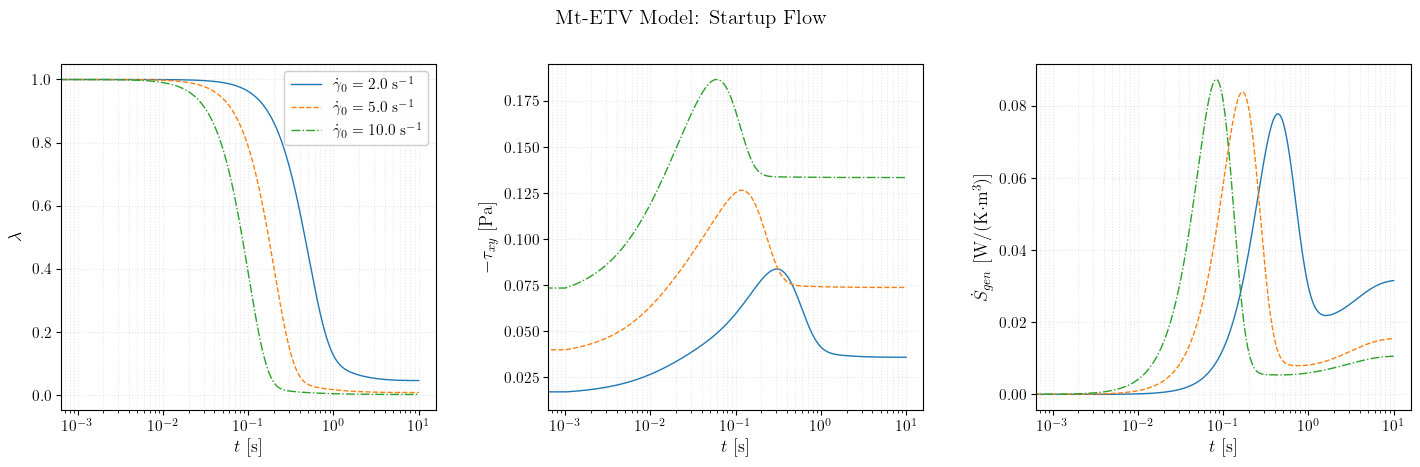

In [26]:
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
linestyles = ['-', '--', '-.']
linewidths = [1, 1, 1]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for idx, g0 in enumerate(gamma0_list):
    r = startup_results[g0]
    label = fr'$\dot{{\gamma}}_0 = {g0}$ s$^{{-1}}$'
    
    axes[0].plot(r['t'], r['y'][8, :], 
                color=colors[idx], linestyle=linestyles[idx], linewidth=linewidths[idx],
                label=label)
    axes[1].plot(r['t'], -r['tauxy'], 
                color=colors[idx], linestyle=linestyles[idx], linewidth=linewidths[idx])
    axes[2].plot(r['t'], r['sgen'], 
                color=colors[idx], linestyle=linestyles[idx], linewidth=linewidths[idx])

axes[0].set_ylabel(r'$\lambda$', fontsize=13, fontweight='bold')
axes[1].set_ylabel(r'$-\tau_{{xy}}$ [Pa]', fontsize=13, fontweight='bold')
axes[2].set_ylabel(r'$\dot{{S}}_{{gen}}$ [W/(K$\cdot$m$^3$)]', fontsize=13, fontweight='bold')

for ax in axes:
    ax.set_xlabel(r'$t$ [s]', fontsize=13, fontweight='bold')
    ax.set_xscale('log')
    ax.grid(True, which='both', alpha=0.3, linestyle=':', linewidth=0.8)
    ax.tick_params(labelsize=11)

axes[0].legend(fontsize=11, loc='best', framealpha=0.95)

fig.suptitle('Mt-ETV Model: Startup Flow', fontsize=15, fontweight='bold', y=1.00)
plt.subplots_adjust(left=0.08, right=0.98, wspace=0.3)
plt.savefig(os.path.join(FIGURE_DIR, 'startup.png'), dpi=300, bbox_inches='tight')
print(f"Saved to {FIGURE_DIR}/startup.png")
plt.show()

## 14. Protocol 2: Stress Relaxation

After reaching steady state in startup flow, the shear rate is suddenly set to zero ($\dot{\gamma}_0 \to 0$). The system then relaxes back toward equilibrium. The structure parameter $\lambda$ recovers toward 1 (full aggregation), stress decays, and entropy generation diminishes.

**Time domain**: $t \in [0, 20]$ s with logarithmic resolution.

In [27]:
t_relax_span = (0.0, 20.0)
t_relax_eval = np.concatenate([[0.0], np.logspace(-3, np.log10(20.0), 999)])
t_relax_eval = np.sort(np.unique(np.clip(t_relax_eval, 0, 20.0)))

relax_results = {}

print("Running stress relaxation (Mt-ETV)...")
for g0 in gamma0_list:
    y_init = startup_results[g0]['y'][:, -1]
    
    sol = solve_ivp(
        lambda t, y: rhs_wrapper(t, y, 0.0, params_tuple),
        t_relax_span,
        y_init,
        t_eval=t_relax_eval,
        **INTEGRATOR_OPTS
    )
    
    tauxy = np.array([tauxy_func(*sol.y[:, k], 0.0, *params_tuple) for k in range(len(sol.t))])
    sgen = np.array([sdot_gen_func(*sol.y[:, k], 0.0, *params_tuple) for k in range(len(sol.t))])
    
    relax_results[g0] = {'t': sol.t, 'y': sol.y, 'tauxy': tauxy, 'sgen': sgen}
    print(f"  ✓ gamma0 = {g0} 1/s (relaxation)")

relax_data = {'t': t_relax_eval}
for g0 in gamma0_list:
    r = relax_results[g0]
    relax_data[f'lam_g{g0}'] = r['y'][8, :]
    relax_data[f'tauxy_g{g0}'] = r['tauxy']
    relax_data[f'sgen_g{g0}'] = r['sgen']

np.savez(os.path.join(OUTPUT_DIR, 'relaxation.npz'), **relax_data)
print(f"Saved to {OUTPUT_DIR}/relaxation.npz\n")

Running stress relaxation (Mt-ETV)...
  ✓ gamma0 = 2.0 1/s (relaxation)
  ✓ gamma0 = 5.0 1/s (relaxation)
  ✓ gamma0 = 10.0 1/s (relaxation)
Saved to data/Mt-ETV/relaxation.npz



Saved to figs/Mt-ETV/relaxation.png


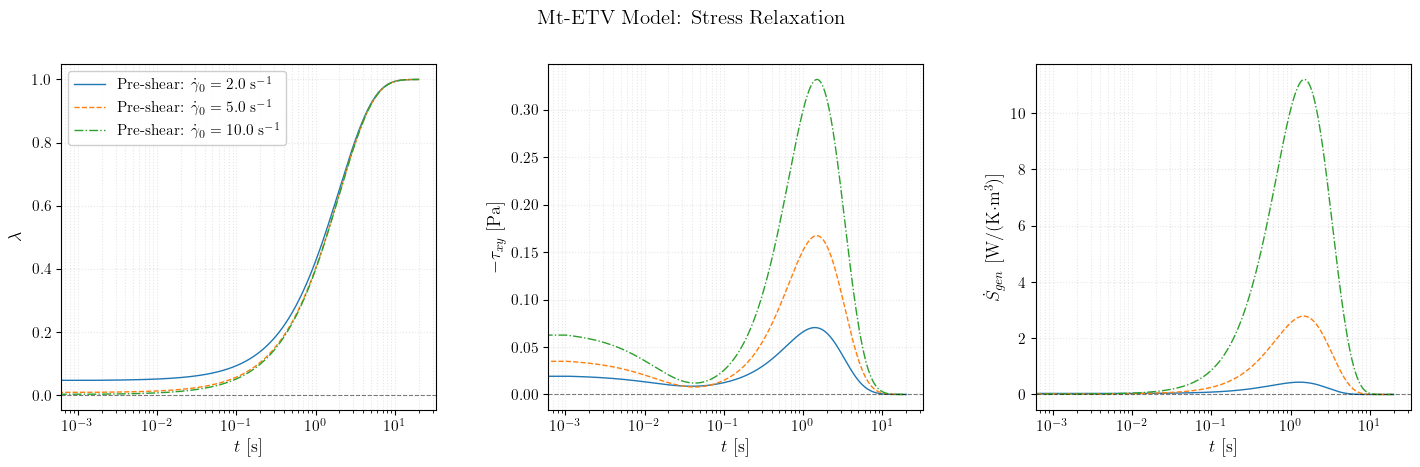

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for idx, g0 in enumerate(gamma0_list):
    r = relax_results[g0]
    label = fr'Pre-shear: $\dot{{\gamma}}_0 = {g0}$ s$^{{-1}}$'
    
    axes[0].plot(r['t'], r['y'][8, :], 
                color=colors[idx], linestyle=linestyles[idx], linewidth=linewidths[idx],
                label=label)
    axes[1].plot(r['t'], -r['tauxy'], 
                color=colors[idx], linestyle=linestyles[idx], linewidth=linewidths[idx])
    axes[2].plot(r['t'], r['sgen'], 
                color=colors[idx], linestyle=linestyles[idx], linewidth=linewidths[idx])

axes[0].set_ylabel(r'$\lambda$', fontsize=13, fontweight='bold')
axes[1].set_ylabel(r'$-\tau_{{xy}}$ [Pa]', fontsize=13, fontweight='bold')
axes[2].set_ylabel(r'$\dot{{S}}_{{gen}}$ [W/(K$\cdot$m$^3$)]', fontsize=13, fontweight='bold')

for ax in axes:
    ax.set_xlabel(r'$t$ [s]', fontsize=13, fontweight='bold')
    ax.set_xscale('log')
    ax.grid(True, which='both', alpha=0.3, linestyle=':', linewidth=0.8)
    ax.axhline(0, color='k', linewidth=0.8, linestyle='--', alpha=0.5)
    ax.tick_params(labelsize=11)

axes[0].legend(fontsize=11, loc='best', framealpha=0.95)

fig.suptitle('Mt-ETV Model: Stress Relaxation', fontsize=15, fontweight='bold', y=1.00)
plt.subplots_adjust(left=0.08, right=0.98, wspace=0.3)
plt.savefig(os.path.join(FIGURE_DIR, 'relaxation.png'), dpi=300, bbox_inches='tight')
print(f"Saved to {FIGURE_DIR}/relaxation.png")
plt.show()

### Protocol 3: Shear Rate Reversal

At time $t_{\text{rev}} = 10$ s, the shear rate switches from $+\dot{\gamma}_0$ to $-\dot{\gamma}_0$. This protocol tests the model's ability to capture flow reversal transients. Results are plotted relative to reversal time.

**Time domain**: $t \in [0, 20]$ s (shifted so $t_{\text{rev}} = 0$ for visualization).

In [29]:
t_rev = 10.0
t_reversal_span = (0.0, 20.0)
t_before = np.logspace(-3, np.log10(t_rev), 500)
t_after = t_rev + np.logspace(-3, np.log10(10.0), 500)
t_reversal_eval = np.concatenate([t_before, t_after])
t_reversal_eval = np.sort(np.unique(np.clip(t_reversal_eval, 0, 20.0)))

reversal_results = {}

print("Running shear rate reversal (Mt-ETV)...")
for g0 in gamma0_list:
    sol = solve_ivp(
        lambda t, y: rhs_wrapper(t, y, g0 if t < t_rev else -g0, params_tuple),
        t_reversal_span,
        y0,
        t_eval=t_reversal_eval,
        **INTEGRATOR_OPTS
    )
    
    gamma_history = np.where(sol.t < t_rev, g0, -g0)
    tauxy = np.array([tauxy_func(*sol.y[:, k], gamma_history[k], *params_tuple) for k in range(len(sol.t))])
    sgen = np.array([sdot_gen_func(*sol.y[:, k], gamma_history[k], *params_tuple) for k in range(len(sol.t))])
    
    mask = sol.t >= t_rev
    reversal_results[g0] = {
        't': sol.t[mask] - t_rev,
        'y': sol.y[:, mask],
        'tauxy': tauxy[mask],
        'sgen': sgen[mask]
    }
    print(f"  ✓ gamma0 = {g0} 1/s (reversed at t={t_rev}s)")

reversal_data = {'t': reversal_results[gamma0_list[0]]['t']}
for g0 in gamma0_list:
    r = reversal_results[g0]
    reversal_data[f'lam_g{g0}'] = r['y'][8, :]
    reversal_data[f'tauxy_g{g0}'] = r['tauxy']
    reversal_data[f'sgen_g{g0}'] = r['sgen']

np.savez(os.path.join(OUTPUT_DIR, 'reversal.npz'), **reversal_data)
print(f"Saved to {OUTPUT_DIR}/reversal.npz\n")

Running shear rate reversal (Mt-ETV)...
  ✓ gamma0 = 2.0 1/s (reversed at t=10.0s)
  ✓ gamma0 = 5.0 1/s (reversed at t=10.0s)
  ✓ gamma0 = 10.0 1/s (reversed at t=10.0s)
Saved to data/Mt-ETV/reversal.npz



Saved to figs/Mt-ETV/reversal.png


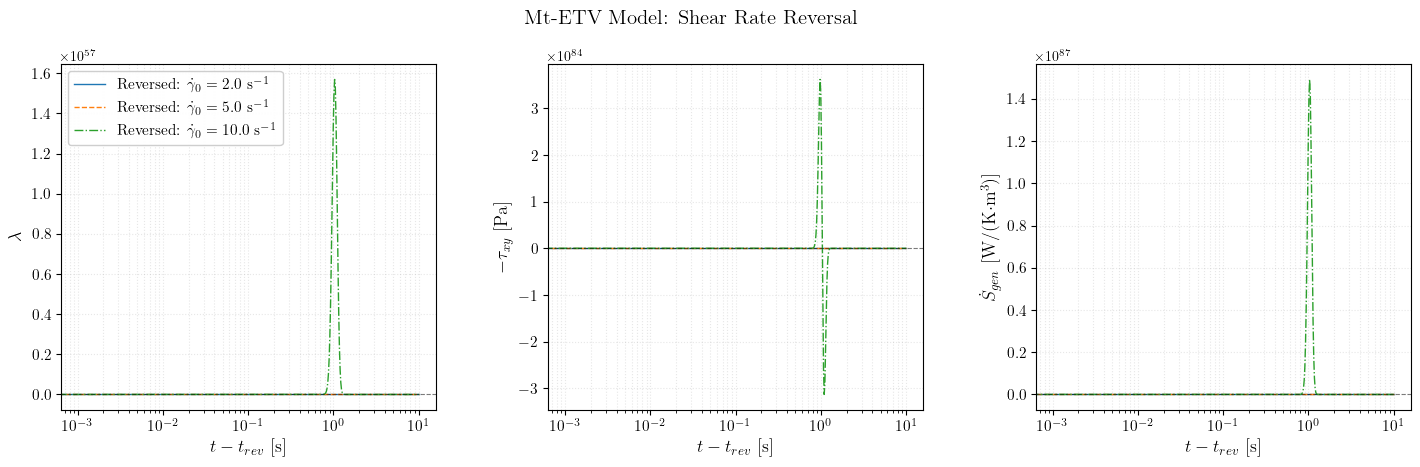

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for idx, g0 in enumerate(gamma0_list):
    r = reversal_results[g0]
    label = fr'Reversed: $\dot{{\gamma}}_0 = {g0}$ s$^{{-1}}$'
    
    axes[0].plot(r['t'], r['y'][8, :], 
                color=colors[idx], linestyle=linestyles[idx], linewidth=linewidths[idx],
                label=label)
    axes[1].plot(r['t'], -r['tauxy'], 
                color=colors[idx], linestyle=linestyles[idx], linewidth=linewidths[idx])
    axes[2].plot(r['t'], r['sgen'], 
                color=colors[idx], linestyle=linestyles[idx], linewidth=linewidths[idx])

axes[0].set_ylabel(r'$\lambda$', fontsize=13, fontweight='bold')
axes[1].set_ylabel(r'$-\tau_{{xy}}$ [Pa]', fontsize=13, fontweight='bold')
axes[2].set_ylabel(r'$\dot{{S}}_{{gen}}$ [W/(K$\cdot$m$^3$)]', fontsize=13, fontweight='bold')

for ax in axes:
    ax.set_xlabel(r'$t - t_{{rev}}$ [s]', fontsize=13, fontweight='bold')
    ax.set_xscale('log')
    ax.grid(True, which='both', alpha=0.3, linestyle=':', linewidth=0.8)
    ax.axhline(0, color='k', linewidth=0.8, linestyle='--', alpha=0.5)
    ax.tick_params(labelsize=11)

axes[0].legend(fontsize=11, loc='best', framealpha=0.95)

fig.suptitle('Mt-ETV Model: Shear Rate Reversal', fontsize=15, fontweight='bold', y=1.00)
plt.subplots_adjust(left=0.08, right=0.98, wspace=0.3)
plt.savefig(os.path.join(FIGURE_DIR, 'reversal.png'), dpi=300, bbox_inches='tight')
print(f"Saved to {FIGURE_DIR}/reversal.png")
plt.show()

In [31]:
# DEBUG CRÍTICO: verificar exactamente qué está pasando
g0_test = 2.0
y_test = y0.copy()

print("=" * 70)
print("CHECKING ARGUMENT ORDER")
print("=" * 70)

# ¿Cuál es el orden correcto de _args?
print(f"\nLambdify was created with _args order:")
print(f"_args = (cCxx, cCxy, cCyy, cCzz, cRxx, cRxy, cRyy, cRzz, lam, gamma0) + param_syms")
print(f"\nSo the order is:")
print(f"Position 0-8: state variables (9 componentes)")
print(f"Position 9: gamma0")
print(f"Position 10-21: parameters (12 parámetros)")

test_args_correct = tuple(y_test) + (g0_test,) + params_tuple

print(f"\ntest_args length: {len(test_args_correct)}")
print(f"Should be: 9 (state) + 1 (gamma0) + 12 (params) = 22")

# Ahora calcular con el orden CORRECTO
tau_correct = tauxy_func(*test_args_correct)
sgen_correct = sdot_gen_func(*test_args_correct)

print(f"\nWith CORRECT order:")
print(f"  tau_xy = {tau_correct}")
print(f"  Sdot_gen = {sgen_correct}")

# Ahora intentar con orden INCORRECTO (para ver si eso causa el problema)
# Por ejemplo, si alguien hiciera: tauxy_func(*y_test, g0_test, *params_tuple)
test_args_wrong = tuple(y_test) + (g0_test,) + tuple(param_dict.values())

print(f"\n" + "=" * 70)
print("Testing different argument orderings:")
print("=" * 70)

try:
    tau_wrong = tauxy_func(*test_args_wrong)
    print(f"\nWith DIFFERENT param order: tau_xy = {tau_wrong}")
except Exception as e:
    print(f"\nWith DIFFERENT param order: ERROR - {e}")

# Ahora verificar qué parámetros está usando
print(f"\n" + "=" * 70)
print("Parameter values being used:")
print(f"=" * 70)
print(f"params_tuple = {params_tuple}")
print(f"\nExpected order: (G_C, muC0, muCinf, tauC, G_R, tau_R, tau_lam, m, tau_aggr, d, rho, T)")
print(f"param_names = {param_names}")

# Verificar si los valores son razonables
print(f"\nParameter values:")
for name, val in zip(param_names, params_tuple):
    print(f"  {name} = {val}")

CHECKING ARGUMENT ORDER

Lambdify was created with _args order:
_args = (cCxx, cCxy, cCyy, cCzz, cRxx, cRxy, cRyy, cRzz, lam, gamma0) + param_syms

So the order is:
Position 0-8: state variables (9 componentes)
Position 9: gamma0
Position 10-21: parameters (12 parámetros)

test_args length: 22
Should be: 9 (state) + 1 (gamma0) + 12 (params) = 22

With CORRECT order:
  tau_xy = -0.015568724881256851
  Sdot_gen = -0.0

Testing different argument orderings:

With DIFFERENT param order: tau_xy = -0.015568724881256851

Parameter values being used:
params_tuple = (0.5471, 0.0082, 0.0034, 0.0474, 0.1552, 1.5, 1.9819, 1.5, 0.0117, 0.5, 1060.0, 310.0)

Expected order: (G_C, muC0, muCinf, tauC, G_R, tau_R, tau_lam, m, tau_aggr, d, rho, T)
param_names = ['G_C', 'muC0', 'muCinf', 'tauC', 'G_R', 'tau_R', 'tau_lam', 'm', 'tau_aggr', 'd', 'rho', 'T']

Parameter values:
  G_C = 0.5471
  muC0 = 0.0082
  muCinf = 0.0034
  tauC = 0.0474
  G_R = 0.1552
  tau_R = 1.5
  tau_lam = 1.9819
  m = 1.5
  tau_aggr

In [18]:
# ------------------------------------------------------------
# Vector de residuos (para least_squares) dado u = log(theta)
# Penalizacion blanda de Sgen < 0 incluida como residuos extra.
# ------------------------------------------------------------
PENALTY_WEIGHT = 50.0   # peso de la penalizacion termodinamica; ajustar si domina demasiado

def residuals(u):
    theta = np.exp(u)
    param_tuple = modelo_param_tuple(theta)

    res_tau, res_lam, res_sgen = [], [], []

    for g0 in gamma0_list:
        sim = integrar_modelo(param_tuple, g0)
        if sim is None:
            # integracion fallida -> residuo grande y constante (mismo tamano que un caso normal)
            res_tau.append(np.full_like(t_eval_opt, 1e3))
            res_lam.append(np.full_like(t_eval_opt, 1e3))
            res_sgen.append(np.zeros_like(t_eval_opt))
            continue

        r_tau = (sim['tauxy'] - targets[g0]['tauxy']) / tau_scale
        r_lam = (sim['lam']   - targets[g0]['lam'])   / lam_scale

        # penalizacion de violacion de la 2a ley: solo penaliza la parte negativa
        sgen_viol = np.minimum(sim['sgen'], 0.0)
        r_sgen = PENALTY_WEIGHT * sgen_viol

        res_tau.append(r_tau)
        res_lam.append(r_lam)
        res_sgen.append(r_sgen)

    return np.concatenate(res_tau + res_lam + res_sgen)

def objetivo_escalar(u):
    r = residuals(u)
    return np.sum(r**2)

In [19]:
# ------------------------------------------------------------
# Etapa 1: busqueda global (differential_evolution) en espacio log
# ------------------------------------------------------------
theta0_vec = np.array([THETA0[k] for k in THETA_KEYS])
u0 = np.log(theta0_vec)

bounds_log = [(u0[i] - 3*np.log(10), u0[i] + 3*np.log(10)) for i in range(len(u0))]

print("Etapa 1: busqueda global (differential_evolution)...")
result_global = differential_evolution(
    objetivo_escalar,
    bounds=bounds_log,
    seed=42,
    maxiter=80,
    popsize=15,
    tol=1e-8,
    polish=False,      # el pulido fino lo hace la etapa 2
    workers=1,          # workers=-1 (multiprocessing) fails to pickle a notebook-local
                    # objective on Windows/Jupyter (__main__ isn't a real importable
                    # module there); keep single-process
    updating='deferred'
)
print("  F(theta) global =", result_global.fun)
print("  theta global    =", np.exp(result_global.x))

NameError: name 'THETA_KEYS' is not defined

In [ ]:
# ------------------------------------------------------------
# Etapa 2: refinamiento local (least_squares, TRF)
# ------------------------------------------------------------
print("Etapa 2: refinamiento local (least_squares)...")
result_local = least_squares(
    residuals,
    x0=result_global.x,
    method='trf',
    xtol=1e-12, ftol=1e-12, gtol=1e-12,
    max_nfev=2000
)

theta_opt = np.exp(result_local.x)
print("  F(theta) final  =", np.sum(result_local.fun**2))
print("\nParametros optimizados:")
for k, v in zip(THETA_KEYS, theta_opt):
    print(f"  {k:10s} = {v:.6g}   (inicial: {THETA0[k]:.6g})")

Etapa 2: refinamiento local (least_squares)...
  F(theta) final  = 4.692752010835811

Parametros optimizados:
  G_R        = 0.171452   (inicial: 0.1552)
  muR        = 0.0174295   (inicial: 0.039)
  m          = 0.499769   (inicial: 1.5)
  tau_lam    = 2.2419e+08   (inicial: 1.9819)
  tau_aggr   = 3.40888e+15   (inicial: 0.0117)


In [ ]:
# ------------------------------------------------------------
# Verificacion final: Sgen >= 0 con los parametros optimizados
# ------------------------------------------------------------
param_tuple_opt = modelo_param_tuple(theta_opt)
print("Verificacion de la 2a ley con theta optimo:")
for g0 in gamma0_list:
    sim = integrar_modelo(param_tuple_opt, g0)
    sgen_min = np.min(sim['sgen'])
    status = "OK" if sgen_min >= -1e-8 else "VIOLACION"
    print(f"  gammadot0={g0:5.1f}  min(Sgen)={sgen_min:.3e}   [{status}]")

Verificacion de la 2a ley con theta optimo:
  gammadot0=  2.0  min(Sgen)=0.000e+00   [OK]
  gammadot0=  5.0  min(Sgen)=0.000e+00   [OK]
  gammadot0= 10.0  min(Sgen)=0.000e+00   [OK]


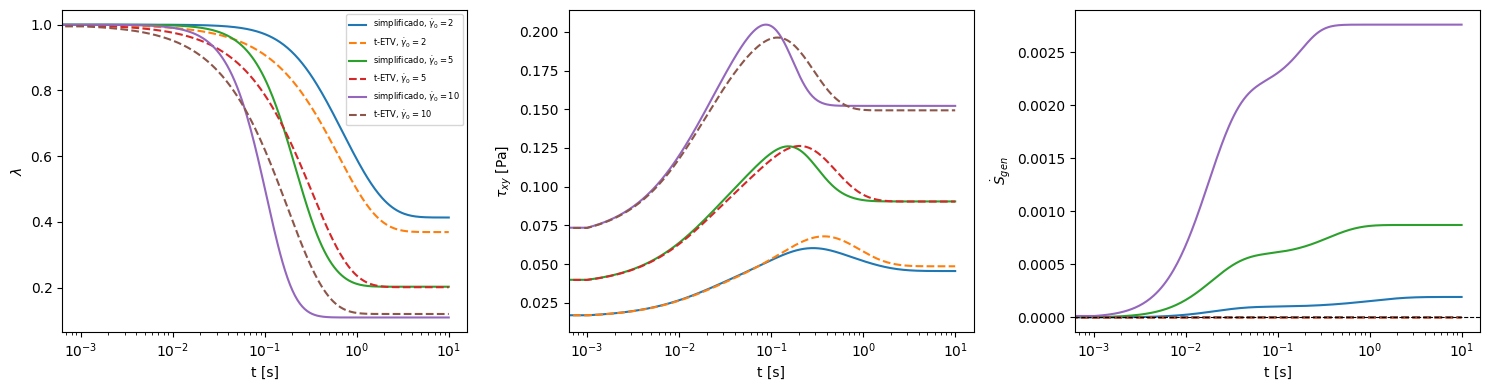

In [ ]:
# ------------------------------------------------------------
# Comparacion grafica: modelo optimizado vs t-ETV
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for g0 in gamma0_list:
    sim = integrar_modelo(param_tuple_opt, g0)
    tgt = targets[g0]

    axes[0].plot(sim['t'], sim['lam'], label=fr'simplificado, $\dot\gamma_0={g0}$')
    axes[0].plot(tgt['t'], tgt['lam'], '--', label=fr't-ETV, $\dot\gamma_0={g0}$')

    axes[1].plot(sim['t'], -sim['tauxy'])
    axes[1].plot(tgt['t'], -tgt['tauxy'], '--')

    axes[2].plot(sim['t'], sim['sgen'])
    axes[2].plot(tgt['t'], tgt['sgen'], '--')

axes[0].set_xlabel('t [s]'); axes[0].set_ylabel(r'$\lambda$')
axes[0].legend(fontsize=6)

axes[1].set_xlabel('t [s]'); axes[1].set_ylabel(r'$\tau_{xy}$ [Pa]')
axes[2].set_xlabel('t [s]'); axes[2].set_ylabel(r'$\dot S_{gen}$')
axes[2].axhline(0, color='k', lw=0.8, ls='--')

for ax in axes:
    ax.set_xscale('log')

plt.tight_layout()

import os
os.makedirs('figs/simplified_mod_t_ETV', exist_ok=True)
fig.savefig('figs/simplified_mod_t_ETV/fit_vs_tETV.png', dpi=150)

plt.show()